In [74]:
#Importation des bibliothèques nécessaire 
from faker import Faker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode,pearsonr
import random
from datetime import datetime,timedelta
from scipy.cluster.vq import whiten, kmeans, vq

## **1. Création des profils d’utilisateurs, des films et de l'historique de visionnage**


In [75]:
#Importation de Faker pour les informations aléatoire
faker = Faker()

In [76]:
#Liste des genres
genres = [
    "Action", "Drame", "Comédie", "Science-Fiction",
    "Thriller", "Horreur", "Romance","Animé"
]

### **Génération des films**

In [77]:
#Liste des films
films = [
    # Science-Fiction
    {"movie": "Inception", "genre": "Science-Fiction", "director": "Christopher Nolan"},{"movie": "Interstellar", "genre": "Science-Fiction", "director": "Christopher Nolan"},{"movie": "The Matrix", "genre": "Science-Fiction", "director": "Lana Wachowski, Lilly Wachowski"},{"movie": "Arrival", "genre": "Science-Fiction", "director": "Denis Villeneuve"},{"movie": "Blade Runner 2049", "genre": "Science-Fiction", "director": "Denis Villeneuve"},{"movie": "Ex Machina", "genre": "Science-Fiction", "director": "Alex Garland"},

    # Action
    {"movie": "Gladiator", "genre": "Action", "director": "Ridley Scott"},{"movie": "The Dark Knight", "genre": "Action", "director": "Christopher Nolan"},{"movie": "Mad Max: Fury Road", "genre": "Action", "director": "George Miller"},{"movie": "Die Hard", "genre": "Action", "director": "John McTiernan"},{"movie": "John Wick", "genre": "Action", "director": "Chad Stahelski"},{"movie": "Mission Impossible: Fallout", "genre": "Action", "director": "Christopher McQuarrie"},

    # Drame
    {"movie": "Forrest Gump", "genre": "Drame", "director": "Robert Zemeckis"},{"movie": "Fight Club", "genre": "Drame", "director": "David Fincher"},{"movie": "Whiplash", "genre": "Drame", "director": "Damien Chazelle"},{"movie": "The Social Network", "genre": "Drame", "director": "David Fincher"},{"movie": "A Beautiful Mind", "genre": "Drame", "director": "Ron Howard"},{"movie": "The Pursuit of Happyness", "genre": "Drame", "director": "Gabriele Muccino"},

    # Crime
    {"movie": "The Godfather", "genre": "Crime", "director": "Francis Ford Coppola"},{"movie": "Goodfellas", "genre": "Crime", "director": "Martin Scorsese"},{"movie": "Pulp Fiction", "genre": "Crime", "director": "Quentin Tarantino"},{"movie": "The Departed", "genre": "Crime", "director": "Martin Scorsese"},{"movie": "Casino", "genre": "Crime", "director": "Martin Scorsese"},{"movie": "Heat", "genre": "Crime", "director": "Michael Mann"},

    # Thriller
    {"movie": "Se7en", "genre": "Thriller", "director": "David Fincher"},{"movie": "Gone Girl", "genre": "Thriller", "director": "David Fincher"},{"movie": "Prisoners", "genre": "Thriller", "director": "Denis Villeneuve"},{"movie": "Parasite", "genre": "Thriller", "director": "Bong Joon-ho"},{"movie": "Oldboy", "genre": "Thriller", "director": "Park Chan-wook"},{"movie": "Zodiac", "genre": "Thriller", "director": "David Fincher"},

    # Horreur
    {"movie": "The Conjuring", "genre": "Horreur", "director": "James Wan"},{"movie": "Get Out", "genre": "Horreur", "director": "Jordan Peele"},{"movie": "Hereditary", "genre": "Horreur", "director": "Ari Aster"},{"movie": "A Quiet Place", "genre": "Horreur", "director": "John Krasinski"},{"movie": "It", "genre": "Horreur", "director": "Andy Muschietti"},{"movie": "The Shining", "genre": "Horreur", "director": "Stanley Kubrick"},

    # Comédie
    {"movie": "Home Alone", "genre": "Comédie", "director": "Chris Columbus"},{"movie": "The Hangover", "genre": "Comédie", "director": "Todd Phillips"},{"movie": "Superbad", "genre": "Comédie", "director": "Greg Mottola"},{"movie": "The Grand Budapest Hotel", "genre": "Comédie", "director": "Wes Anderson"},{"movie": "Yes Man", "genre": "Comédie", "director": "Peyton Reed"},{"movie": "Bruce Almighty", "genre": "Comédie", "director": "Tom Shadyac"},

    # Romance
    {"movie": "Titanic", "genre": "Romance", "director": "James Cameron"},{"movie": "The Notebook", "genre": "Romance", "director": "Nick Cassavetes"},{"movie": "Pride and Prejudice", "genre": "Romance", "director": "Joe Wright"},{"movie": "Before Sunrise", "genre": "Romance", "director": "Richard Linklater"},{"movie": "La La Land", "genre": "Romance", "director": "Damien Chazelle"},{"movie": "A Star Is Born", "genre": "Romance", "director": "Bradley Cooper"},

    # Aventure
    {"movie": "Jurassic Park", "genre": "Aventure", "director": "Steven Spielberg"},{"movie": "Indiana Jones and the Last Crusade", "genre": "Aventure", "director": "Steven Spielberg"},{"movie": "Pirates of the Caribbean", "genre": "Aventure", "director": "Gore Verbinski"},{"movie": "The Revenant", "genre": "Aventure", "director": "Alejandro G. Inarritu"},{"movie": "The Lord of the Rings: The Fellowship of the Ring", "genre": "Aventure", "director": "Peter Jackson"},{"movie": "The Hobbit: An Unexpected Journey", "genre": "Aventure", "director": "Peter Jackson"},

    # Guerre / Historique
    {"movie": "Saving Private Ryan", "genre": "Guerre", "director": "Steven Spielberg"},{"movie": "1917", "genre": "Guerre", "director": "Sam Mendes"},{"movie": "Dunkirk", "genre": "Guerre", "director": "Christopher Nolan"},{"movie": "Schindler's List", "genre": "Historique", "director": "Steven Spielberg"},{"movie": "Oppenheimer", "genre": "Historique", "director": "Christopher Nolan"},{"movie": "The Imitation Game", "genre": "Historique", "director": "Morten Tyldum"},

    # Animation / Animé
    {"movie": "Spirited Away", "genre": "Animé", "director": "Hayao Miyazaki"},{"movie": "Your Name", "genre": "Animé", "director": "Makoto Shinkai"},{"movie": "Toy Story", "genre": "Animation", "director": "John Lasseter"},{"movie": "Inside Out", "genre": "Animation", "director": "Pete Docter"},{"movie": "Ratatouille", "genre": "Animation", "director": "Brad Bird"},{"movie": "WALL-E", "genre": "Animation", "director": "Andrew Stanton"}
]

### **Ajout d'attribut pour compléter la liste des films**

In [78]:
#Ajout de trois autres attributs (year, duration, rate)
for film in films:
    film["year"] = random.randint(1980, 2025)    
    film["duration"] = random.randint(80, 200) 
    film["rate"] = random.randint(1, 5)

In [79]:
#Date de visionnage aléatoire
start_date = datetime.now() - timedelta(days=730) #Début des visonnage : 730 jours en arrière (soit depuis 2 ans )

### **Création des profils utilisateurs avec Faker**

In [80]:
#Creation des utilisateurs
users = []
user_id = 0
history_id = 0
for us in range(200):
    age = random.randint(16,70)
    user_id += 1 
    history_id += 1

    preference = random.sample(genres,k=random.randint(1,3))

    history = []

    for film in random.sample(films, k=random.randint(1, 6)):
        random_days = random.randint(0, 730) #Jour aléatoire entre 0 pour ajourdhui et 730 avant
        date = (start_date + timedelta(days=random_days)).strftime("%Y-%m-%d")
        history.append({
            "history_id" :history_id,
            "user_id" : random.randint(1,200),
            "movie": film["movie"],
            "genre": film["genre"],
            "director": film["director"],
            "rating": random.randint(1, 5),
            "watch_date" : date
        })

    users.append({
        "user_id" : user_id,
        "name" : faker.name(),
        "age" : age,
        "country" : faker.country(),
        "email" : faker.email(),
        "password" : faker.password(),
        "preferences" : preference,
        "watch_history" : history
    })

In [81]:
users[0:2]

[{'user_id': 1,
  'name': 'Scott Walker',
  'age': 16,
  'country': 'Ethiopia',
  'email': 'michaeldunn@example.net',
  'password': '^@6QwmzrIi',
  'preferences': ['Drame'],
  'watch_history': [{'history_id': 1,
    'user_id': 80,
    'movie': 'It',
    'genre': 'Horreur',
    'director': 'Andy Muschietti',
    'rating': 4,
    'watch_date': '2024-10-09'}]},
 {'user_id': 2,
  'name': 'Patricia Glover',
  'age': 57,
  'country': 'Lesotho',
  'email': 'reginaclark@example.org',
  'password': '%o&1r@Zp)g',
  'preferences': ['Romance'],
  'watch_history': [{'history_id': 2,
    'user_id': 7,
    'movie': 'It',
    'genre': 'Horreur',
    'director': 'Andy Muschietti',
    'rating': 1,
    'watch_date': '2026-01-23'},
   {'history_id': 2,
    'user_id': 148,
    'movie': 'Parasite',
    'genre': 'Thriller',
    'director': 'Bong Joon-ho',
    'rating': 2,
    'watch_date': '2024-12-16'}]}]

### **Transformation des datasets en dataframes avec pandas**

In [82]:
df_users = pd.DataFrame(users)

In [83]:
df_users.head()

,user_id,name,age,country,email,password,preferences,watch_history
0,1,Scott Walker,16,Ethiopia,michaeldunn@example.net,^@6QwmzrIi,[Drame],"[{'history_id': 1, 'user_id': 80, 'movie': 'It..."
1,2,Patricia Glover,57,Lesotho,reginaclark@example.org,%o&1r@Zp)g,[Romance],"[{'history_id': 2, 'user_id': 7, 'movie': 'It'..."
2,3,Samantha Gallegos,44,Guyana,jenniferrobinson@example.org,*0uZXc*ds0,"[Horreur, Romance, Comédie]","[{'history_id': 3, 'user_id': 165, 'movie': 'D..."
3,4,Cindy Little,55,Liechtenstein,justin87@example.org,kcT5Qdeao*,"[Action, Romance, Horreur]","[{'history_id': 4, 'user_id': 80, 'movie': 'In..."
4,5,Todd Flynn,55,Ghana,kristinapeterson@example.net,Z8DSCSgl!5,"[Thriller, Romance]","[{'history_id': 5, 'user_id': 198, 'movie': 'L..."


In [84]:
#Création de l'historique de l'utilsateur (issu du dataframe df_users)
new_history = []

for histories in df_users['watch_history']:
    for film in histories:
        new_history.append(film)

df_watch_history = pd.DataFrame(new_history)

In [85]:
df_watch_history.head()

,history_id,user_id,movie,genre,director,rating,watch_date
0,1,80,It,Horreur,Andy Muschietti,4,2024-10-09
1,2,7,It,Horreur,Andy Muschietti,1,2026-01-23
2,2,148,Parasite,Thriller,Bong Joon-ho,2,2024-12-16
3,3,165,Dunkirk,Guerre,Christopher Nolan,4,2026-03-24
4,3,23,Toy Story,Animation,John Lasseter,4,2026-01-27


In [86]:
#Dataframe des films
df_film = pd.DataFrame(films)

In [87]:
df_film.head()

,movie,genre,director,year,duration,rate
0,Inception,Science-Fiction,Christopher Nolan,1988,160,3
1,Interstellar,Science-Fiction,Christopher Nolan,2009,110,1
2,The Matrix,Science-Fiction,"Lana Wachowski, Lilly Wachowski",2001,94,4
3,Arrival,Science-Fiction,Denis Villeneuve,1997,152,2
4,Blade Runner 2049,Science-Fiction,Denis Villeneuve,1980,91,5


In [88]:
df_users.head()

,user_id,name,age,country,email,password,preferences,watch_history
0,1,Scott Walker,16,Ethiopia,michaeldunn@example.net,^@6QwmzrIi,[Drame],"[{'history_id': 1, 'user_id': 80, 'movie': 'It..."
1,2,Patricia Glover,57,Lesotho,reginaclark@example.org,%o&1r@Zp)g,[Romance],"[{'history_id': 2, 'user_id': 7, 'movie': 'It'..."
2,3,Samantha Gallegos,44,Guyana,jenniferrobinson@example.org,*0uZXc*ds0,"[Horreur, Romance, Comédie]","[{'history_id': 3, 'user_id': 165, 'movie': 'D..."
3,4,Cindy Little,55,Liechtenstein,justin87@example.org,kcT5Qdeao*,"[Action, Romance, Horreur]","[{'history_id': 4, 'user_id': 80, 'movie': 'In..."
4,5,Todd Flynn,55,Ghana,kristinapeterson@example.net,Z8DSCSgl!5,"[Thriller, Romance]","[{'history_id': 5, 'user_id': 198, 'movie': 'L..."


### **Ajout de données manquante et de doublons**

In [89]:
#Ajout de donnée manquante pour les utilisateurs
for m in range(15) :
    ligne = random.randint(0,len(df_users))
    colonne = random.choice(df_users.columns[1:],) #user_id n'est pas inclu
    df_users.loc[ligne,colonne] = np.nan

In [90]:
#Ajout de donnée manquante pour watch_history
for m in range(10) :
    ligne = random.randint(0,len(df_watch_history))
    df_watch_history.loc[ligne,'rating'] = np.nan

### **Ajout des doublons**

In [91]:
#Doublons pour les utilisateurs
doublons_users = df_users.sample(10,random_state=42)
df_users = pd.concat([df_users,doublons_users],ignore_index=True)

In [92]:
# Doublons pour les films
doublons_films = df_film.sample(5,random_state=42)
df_film = pd.concat([df_film,doublons_films],ignore_index=True)

### **Data cleaning**

#### **Cleaning de users**

In [93]:
#Il y a déjà un Dataframe dédié au films déjà regarder, donc il n'est pas essentiel de garder cette colonne
df_users = df_users.drop('watch_history',axis = 1)

In [94]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      210 non-null    int64  
 1   name         207 non-null    object 
 2   age          207 non-null    float64
 3   country      206 non-null    object 
 4   email        208 non-null    object 
 5   password     210 non-null    object 
 6   preferences  207 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 11.6+ KB


In [95]:
df_users.isnull().sum()

user_id        0
name           3
age            3
country        4
email          2
password       0
preferences    3
dtype: int64

La colonne name compte 3 valeurs manquantes, age (5 valeurs maquantes), country (2), email (2), password (2), preferences (1)

In [96]:
df_users['age'] = df_users['age'].fillna(df_users['age'].median())

In [97]:
df_users.isnull().sum()

user_id        0
name           3
age            0
country        4
email          2
password       0
preferences    3
dtype: int64

In [98]:
df_users = df_users[df_users['preferences'].notnull()]
df_users = df_users[df_users['password'].notnull()]
df_users['name'] = df_users['name'].fillna('Non renseigné') 
df_users['country'] = df_users['country'].fillna('Non renseigné') 
df_users['email'] = df_users['email'].fillna('Non renseigné') 

In [99]:
df_users.isnull().sum()

user_id        0
name           0
age            0
country        0
email          0
password       0
preferences    0
dtype: int64

In [100]:
#Vérification de la présence de doublon
df_users[['user_id','name','age','country','email','password']].duplicated().sum()

np.int64(10)

In [101]:
#Supppression des doublons en gardant les colonnes de type list
df_users = df_users.drop_duplicates(subset=['user_id','name','age','country','email','password'])

#### **Cleaning watch_history**

In [102]:
df_watch_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   history_id  680 non-null    int64  
 1   user_id     680 non-null    int64  
 2   movie       680 non-null    object 
 3   genre       680 non-null    object 
 4   director    680 non-null    object 
 5   rating      670 non-null    float64
 6   watch_date  680 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 37.3+ KB


In [103]:
# Convertion de la colonne watch_date qui est de type objet en date
df_watch_history['watch_date'] = pd.to_datetime(df_watch_history['watch_date'])

In [104]:
#Feature engeneering
df_watch_history['year'] = df_watch_history['watch_date'].dt.year
df_watch_history['month'] = df_watch_history['watch_date'].dt.month

In [105]:
df_watch_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   history_id  680 non-null    int64         
 1   user_id     680 non-null    int64         
 2   movie       680 non-null    object        
 3   genre       680 non-null    object        
 4   director    680 non-null    object        
 5   rating      670 non-null    float64       
 6   watch_date  680 non-null    datetime64[ns]
 7   year        680 non-null    int32         
 8   month       680 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2), object(3)
memory usage: 42.6+ KB


In [106]:
df_watch_history.duplicated().sum()

np.int64(0)

In [107]:
df_watch_history.isnull().sum()

history_id     0
user_id        0
movie          0
genre          0
director       0
rating        10
watch_date     0
year           0
month          0
dtype: int64

10 valeurs manquantes pour rating

In [108]:
df_watch_history['rating'] = df_watch_history['rating'].fillna(df_watch_history["rating"].mean())

In [109]:
df_watch_history.isnull().sum()

history_id    0
user_id       0
movie         0
genre         0
director      0
rating        0
watch_date    0
year          0
month         0
dtype: int64

#### **Cleaning films**

In [110]:
df_film.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie     71 non-null     object
 1   genre     71 non-null     object
 2   director  71 non-null     object
 3   year      71 non-null     int64 
 4   duration  71 non-null     int64 
 5   rate      71 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 3.5+ KB


In [111]:
df_film.isnull().sum()

movie       0
genre       0
director    0
year        0
duration    0
rate        0
dtype: int64

Aucune valeur manquante

In [112]:
df_film.duplicated().sum()

np.int64(5)

In [113]:
df_film = df_film.drop_duplicates()

Et ainsi on fini de traiter nos données, on peut passer à leurs utilisations

## **2. Création du moteur de recommandation :**

### **2.1 Filtrer les films en fonction des préférences de l'utilisateur.**

In [114]:
preferences = df_users.loc[0, 'preferences']

In [115]:
preferences

['Drame']

In [116]:
def preferences_films(preferences):
    films = df_film[df_film['genre'].isin(preferences)]
    return films

# Préférences du premier utilisateur
prefs = preferences

print("Films conseillés :")
all_pref = preferences_films(prefs)

for movie in all_pref['movie']:
    print(f"{movie}, ",end='')

Films conseillés :
Forrest Gump, Fight Club, Whiplash, The Social Network, A Beautiful Mind, The Pursuit of Happyness, 

On passe les préférences de l'utilisation à la fonction preferences_films, puis on récupère tous les films qui sont de ces genres et on affiche leurs titres à l'utilsateurs

### **2.2 Classement des films en fonction des notes des utilisateurs ou des similitudes de genre**

#### **Classement selon les notes des utilisateurs**

In [117]:
def ranking (df_film) :
    df_film_ranking = df_film.sort_values('rate',ascending=False)
    return df_film_ranking

df = ranking(df_film)
print('Voici la liste des films conseillé en fonction de la notation :')
for movie in df['movie']:
    print(f"{movie}, ",end='')

Voici la liste des films conseillé en fonction de la notation :
The Dark Knight, Blade Runner 2049, Pirates of the Caribbean, Toy Story, Die Hard, Mission Impossible: Fallout, A Quiet Place, Hereditary, Get Out, The Godfather, The Conjuring, Schindler's List, Spirited Away, WALL-E, Before Sunrise, A Star Is Born, Superbad, The Shining, The Imitation Game, Your Name, Zodiac, The Social Network, Dunkirk, Casino, Goodfellas, Pride and Prejudice, Gladiator, Forrest Gump, John Wick, Gone Girl, The Matrix, Inception, The Revenant, Parasite, A Beautiful Mind, Saving Private Ryan, Titanic, La La Land, Prisoners, Yes Man, The Hangover, Home Alone, Ratatouille, Mad Max: Fury Road, Arrival, Ex Machina, Heat, Fight Club, The Pursuit of Happyness, The Departed, The Hobbit: An Unexpected Journey, Oppenheimer, Se7en, Oldboy, Bruce Almighty, It, The Lord of the Rings: The Fellowship of the Ring, Jurassic Park, Interstellar, Whiplash, Pulp Fiction, The Grand Budapest Hotel, Indiana Jones and the Last C

On affiche les films en fonction du rate

#### **Classement selon la similitude de genre**

In [118]:
def similarity(genre, preferences):
    if genre in preferences:
        return 1
    return 0

def ranking_similarity(df_film, preferences, top_n=10):
    df_film_similarity = df_film.copy()
    df_film_similarity['score_similarite'] = df_film_similarity['genre'].apply(
        lambda genre: similarity(genre, preferences)
    )
    df_film_similarity = df_film_similarity.sort_values(
        by=['score_similarite', 'rate', 'year'],
        ascending=[False, False, False]
    )

    return df_film_similarity.head(top_n)[
        ['movie', 'genre', 'rate', 'year', 'score_similarite']
    ]

df_similarity = ranking_similarity(df_film, prefs)

print('Préférences de l\'utilisateur :', prefs)
print('Voici le classement des films conseillés selon la similitude de genre :')
for movie in df_similarity['movie']:
    print(f"{movie}, ",end='')

Préférences de l'utilisateur : ['Drame']
Voici le classement des films conseillés selon la similitude de genre :
Forrest Gump, The Social Network, A Beautiful Mind, Fight Club, The Pursuit of Happyness, Whiplash, The Dark Knight, A Quiet Place, Toy Story, Get Out, 

On passe les films et les préférence de l'utilisateur à la fonction ranking_similarity, puis on vérifie si le genre du film est présent dans les préférence du l'utilisateur, si c'est le cas on ajoute 1 pour dire que le film est similaire au préférence de l'utilisateur

**Exemple d'affichage**

In [119]:
user = df_users.loc[0]
user_see = df_watch_history[df_watch_history['user_id']==user['user_id']]

In [120]:
#Vu que les date sont généré de manière aléatoire (on organise et ça et on prend le nom film avec la dernière date)
last_see = user_see.sort_values('watch_date').iloc[-1]['movie']

In [121]:
suggestion =  df_similarity.iloc[0]['movie']

In [122]:
#Suggestion basé sur les similiarité
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {suggestion}')

Scott Walker, vous avez regarder La La Land, peut-être que vous aimeriez Forrest Gump


In [123]:
suggestion_note =  df.iloc[0]['movie']

In [124]:
#Suggestion basé sur les notes
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {suggestion_note}')

Scott Walker, vous avez regarder La La Land, peut-être que vous aimeriez The Dark Knight


In [125]:
suggestion_all_pref =  all_pref.iloc[0]['movie']

In [126]:
#Suggestion basé sur la note
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {suggestion_note}')

Scott Walker, vous avez regarder La La Land, peut-être que vous aimeriez The Dark Knight


### **Pearsonr**

In [127]:
def correlation_pearson_utilisateurs(df_watch_history, user_id_1, user_id_2):
    # Récupérer les films et les notes du premier utilisateur
    user1_ratings = df_watch_history[df_watch_history["user_id"] == user_id_1][
        ["movie", "rating"]
    ]

    # Récupérer les films et les notes du deuxième utilisateur
    user2_ratings = df_watch_history[df_watch_history["user_id"] == user_id_2][
        ["movie", "rating"]
    ]

    # Garder seulement les films regardés par les deux utilisateurs
    common_movies = pd.merge(
        user1_ratings,
        user2_ratings,
        on="movie",
        suffixes=("_user1", "_user2")
    )

    # Pearson a besoin d'au moins 2 films en commun
    if len(common_movies) < 2:
        return None

    correlation, p_value = pearsonr(
        common_movies["rating_user1"],
        common_movies["rating_user2"]
    )

    return correlation

user_id_1 = df_watch_history["user_id"].unique()[0]
user_id_2 = df_watch_history["user_id"].unique()[1]

resultat = correlation_pearson_utilisateurs(
    df_watch_history,
    user_id_1,
    user_id_2
)

print("Utilisateur 1 :", user_id_1)
print("Utilisateur 2 :", user_id_2)
print("Corrélation Pearson :", resultat)

Utilisateur 1 : 80
Utilisateur 2 : 7
Corrélation Pearson : None


### **Klustering K-Means avec Scipy**

On va transformer les goûts des utilisateurs en nombres afin que K-Means puisse les analyser.
On va en quelque grouper les aditionner les notes attribué aux films par les utilsateurs en fonction de chaque utilisateurs et de chaque catégorie de film

In [128]:
genre_user = []
for us in users:
    vec = []
    for genre in genres:

        score = 0
        for movie in us["watch_history"]:

            if movie["genre"] == genre:
                score += movie["rating"]
        vec.append(score)
    genre_user.append(vec)
                
df_genre = pd.DataFrame(
    genre_user,
    columns=genres
)

In [129]:
df_genre

,Action,Drame,Comédie,Science-Fiction,Thriller,Horreur,Romance,Animé
0,0,0,0,0,0,4,0,0
1,0,0,0,0,2,1,0,0
2,0,0,0,0,0,0,0,0
3,0,0,2,0,0,0,0,0
4,0,6,0,5,0,0,7,0
...,...,...,...,...,...,...,...,...
195,0,0,5,0,0,0,5,0
196,0,3,2,0,0,4,0,0
197,0,5,0,5,0,0,4,0
198,0,0,4,0,5,0,0,0


### **Normalisation**

Dans df_genre on voit que score varie entre les catégorie de film, le modèle peut souvent apprendre de la catégorie avec la meilleure note (la plus élévé comparé aux autres), whiten est plus utilisé avec k-means

In [130]:
X = whiten(df_genre)

In [131]:
X

array([[0.        , 0.        , 0.        , ..., 2.15841303, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.53960326, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 2.70964902, 0.        , ..., 0.        , 1.95811007,
        0.        ],
       [0.        , 0.        , 2.48357396, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(200, 8))

### **Clustering**

vq = Vector Quantization.

In [132]:
k = 3 #Création de 3 groupes d'utilisateur (par exemple grp 1 : Action, grp 2: romance, grp 3 : comédie)

centroids, distortion = kmeans(X, k) #distorsion mésure la qualité du clustering (plus cette valeur
                                     # est faibles, plus les utilisateurs sont proches de leur centre)

clusters, _ = vq(X, centroids) #On assigne chaque utilisateurs dans un groupe

df_genre["cluster"] = clusters #On ajoute chaque résultat au dataframe

In [133]:
df_genre['cluster'].unique()

array([2, 0, 1], dtype=int32)

On remarque qu'il y a trois catégorie d'utilisateurs

### **Recommandation par cluster**

Avant tout, on va créer un nouveau qui va contenir tout notre historique de film regarder par les utilisateur ainsi que leur note attribuer

In [134]:
ratings = []

for user_id, user in enumerate(users):

    for movie in user["watch_history"]:

        ratings.append({
            "user": user_id,
            "movie": movie["movie"],
            "rating": movie["rating"]
        })

df_rating = pd.DataFrame(ratings)

In [135]:
df_rating.head()

,user,movie,rating
0,0,It,4
1,1,It,1
2,1,Parasite,2
3,2,Dunkirk,4
4,2,Toy Story,4


In [136]:
df_rating["cluster"] = df_rating["user"].map(
    df_genre["cluster"]
)

def recommend_cluster_movies(user_id):

    cluster = df_genre.loc[user_id, "cluster"]

    movies = df_rating[
        df_rating["cluster"] == cluster
    ]

    recommendations = (
        movies.groupby("movie")["rating"]
        .mean()
        .sort_values(ascending=False)
    )

    return recommendations.head(5)
id_user = df_users.loc[0,'user_id']
movie_rec = recommend_cluster_movies(id_user)

In [137]:
#Suggestion basé sur le clustering
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {movie_rec.index[0]}')

Bryan Shaw DVM, vous avez regarder La La Land, peut-être que vous aimeriez Get Out


## **3. Analyse et visualisation des informations :**

In [138]:
user_watch_history = df_watch_history[df_watch_history['user_id'] == user['user_id']]

In [139]:
user_watch_history['genre'].value_counts()

genre
Comédie      2
Animation    1
Animé        1
Aventure     1
Name: count, dtype: int64

Historique de visionnage de l'utilisateur :


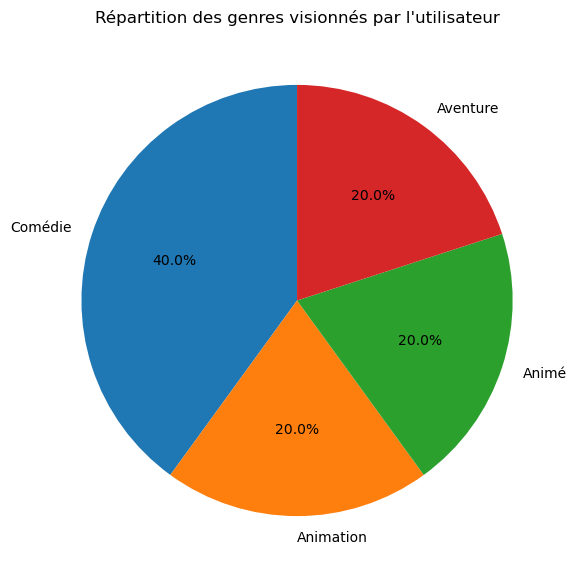

In [140]:
# Affichage de l'historique
print("Historique de visionnage de l'utilisateur :")

# 1. Répartition des genres

genre_counts = user_watch_history['genre'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des genres visionnés par l'utilisateur")
plt.show()

L'utilisateur regarde plus les fims de comédie

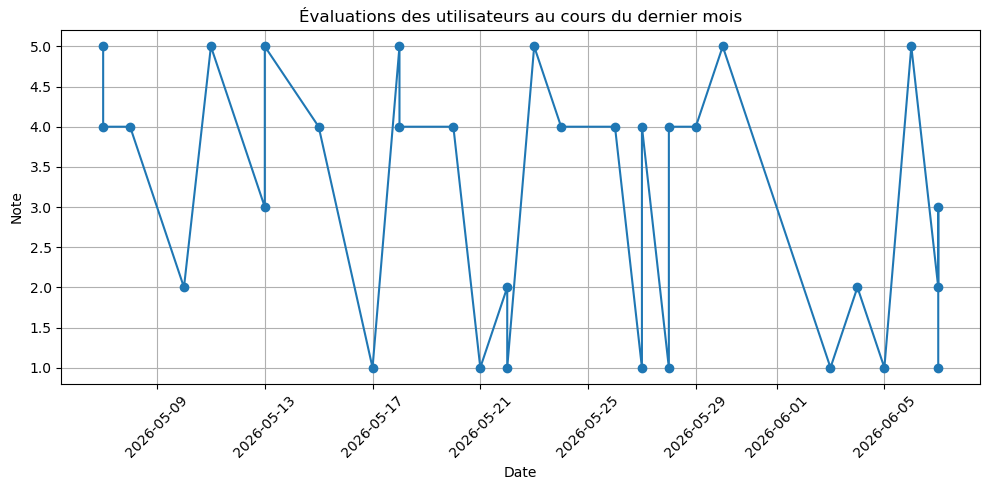

In [141]:
# Date la plus récente du dataset
last_date = df_watch_history['watch_date'].max()

# Données du dernier mois
last_month = df_watch_history[
    df_watch_history['watch_date'] >= last_date - pd.DateOffset(months=1)
]

# Tri par date
last_month = last_month.sort_values('watch_date')

plt.figure(figsize=(10, 5))

plt.plot(
    last_month['watch_date'],
    last_month['rating'],
    marker='o'
)

plt.title("Évaluations des utilisateurs au cours du dernier mois")
plt.xlabel("Date")
plt.ylabel("Note")
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Bonus** (Genre les mieux notées et mals notés)

In [142]:
df_watch_history[(df_watch_history['rating']>=4) & (df_watch_history['watch_date']>'2026-5-1')]['genre'].value_counts()

genre
Horreur            4
Crime              3
Comédie            3
Aventure           2
Science-Fiction    2
Romance            2
Drame              2
Guerre             1
Animé              1
Animation          1
Name: count, dtype: int64

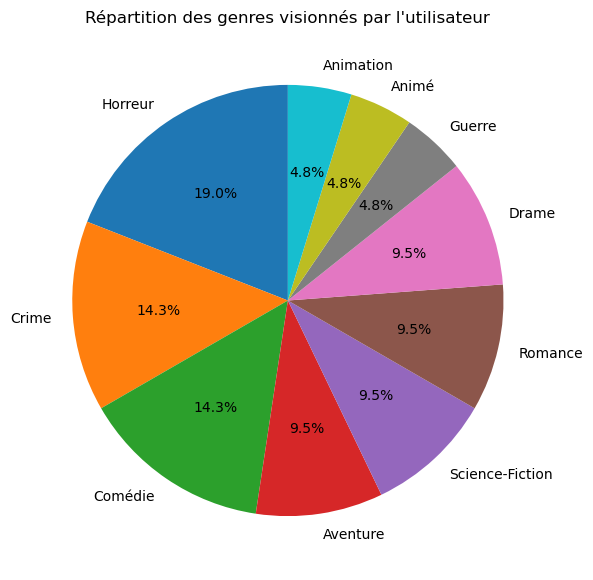

In [143]:
genre = df_watch_history[(df_watch_history['rating']>=4) & (df_watch_history['watch_date']>'2026-5-1')]['genre'].value_counts()
plt.figure(figsize=(7, 7))

plt.pie(
    genre,
    labels=genre.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des genres visionnés par l'utilisateur")
plt.show()

On constate que les notes des utilisateurs ne sont pas constante mais varie fortement, les utilsateurs on plus aimé les films d'horreur, de crime et de comédie que les autres

In [144]:
df_watch_history[(df_watch_history['rating']<=2) & (df_watch_history['watch_date']>'2026-5-1')]['genre'].value_counts()

genre
Comédie            2
Science-Fiction    2
Romance            2
Historique         2
Action             1
Crime              1
Thriller           1
Drame              1
Animé              1
Name: count, dtype: int64

In [145]:
df_watch_history[(df_watch_history['rating']<=2) & (df_watch_history['watch_date']>'2026-5-1')]

,history_id,user_id,movie,genre,director,rating,watch_date,year,month
7,4,119,The Hangover,Comédie,Todd Phillips,2.0,2026-06-07,2026,6
41,18,11,Die Hard,Action,John McTiernan,1.0,2026-05-22,2026,5
135,41,101,Blade Runner 2049,Science-Fiction,Denis Villeneuve,1.0,2026-05-17,2026,5
219,69,182,Pulp Fiction,Crime,Quentin Tarantino,1.0,2026-05-06,2026,5
303,89,35,La La Land,Romance,Damien Chazelle,1.0,2026-06-03,2026,6
312,91,34,Prisoners,Thriller,Denis Villeneuve,1.0,2026-06-07,2026,6
316,93,13,Fight Club,Drame,David Fincher,1.0,2026-05-28,2026,5
342,99,11,Oppenheimer,Historique,Christopher Nolan,2.0,2026-06-04,2026,6
388,113,93,Your Name,Animé,Makoto Shinkai,1.0,2026-05-21,2026,5
395,115,62,The Matrix,Science-Fiction,"Lana Wachowski, Lilly Wachowski",1.0,2026-05-27,2026,5


Certains films de comédie comme **The Hangover** n'ont pas été aimé, pareil pour certains films science-Fiction comme **Blade Runner 2049** ainsi que certain film de romance et historique